In [40]:
from datetime import datetime
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

In [41]:
data = pd.read_csv('ERCOT-LMP-AZURE-2023h.csv')
data

,sced_timestamp,market,location,location_type,lmp
0,2023-01-01 00:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,34.60
1,2023-01-01 01:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,9.48
2,2023-01-01 02:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,9.29
3,2023-01-01 03:00:19+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,5.18
4,2023-01-01 04:00:17+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,-0.84
...,...,...,...,...,...
4112,2023-06-21 11:00:19+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,21.91
4113,2023-06-21 12:00:23+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,23.71
4114,2023-06-21 13:00:18+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,22.61
4115,2023-06-21 14:00:17+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,25.06


In [42]:
data['date_time'] = pd.to_datetime(data['sced_timestamp'])
data.set_index('date_time', inplace=True)


<Axes: title={'center': 'LMP'}, xlabel='Year', ylabel='lmp'>

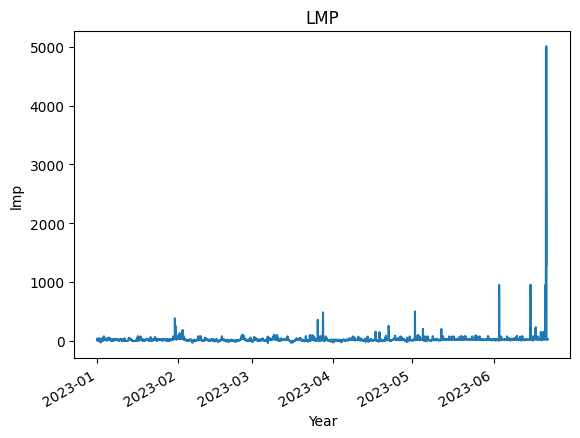

In [43]:
data['lmp'].plot(kind ='line', title='LMP', xlabel='Year', ylabel='lmp')

In [44]:
data['predicted'] = np.nan
for i in range(24 * 7 * 4, len(data)):
    indices = np.array(range(-4, 0)) * 24 * 7 + i
    mean_value = data['lmp'].iloc[indices.tolist()].mean()
    data.at[data.index[i], 'predicted'] = mean_value
data


,sced_timestamp,market,location,location_type,lmp,predicted
date_time,,,,,,
2023-01-01 00:00:16+00:00,2023-01-01 00:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,34.60,NaN
2023-01-01 01:00:16+00:00,2023-01-01 01:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,9.48,NaN
2023-01-01 02:00:16+00:00,2023-01-01 02:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,9.29,NaN
2023-01-01 03:00:19+00:00,2023-01-01 03:00:19+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,5.18,NaN
2023-01-01 04:00:17+00:00,2023-01-01 04:00:17+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,-0.84,NaN
...,...,...,...,...,...,...
2023-06-21 11:00:19+00:00,2023-06-21 11:00:19+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,21.91,20.0225
2023-06-21 12:00:23+00:00,2023-06-21 12:00:23+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,23.71,19.7200
2023-06-21 13:00:18+00:00,2023-06-21 13:00:18+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,22.61,23.2150


<Axes: xlabel='Time', ylabel='"LMP $kW'>

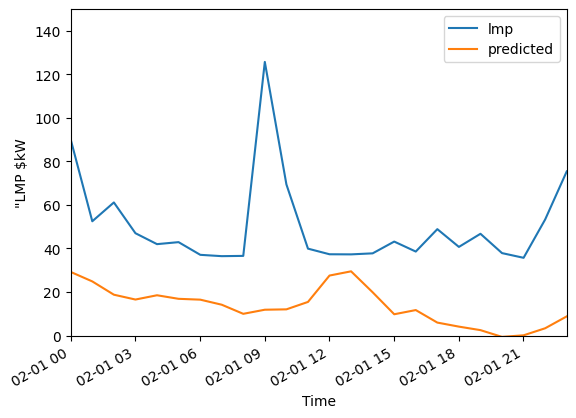

In [51]:
data_for_graph = data[['lmp', 'predicted']]
data_for_graph.plot(kind='line', xlabel='Time', ylabel='"LMP $kW', ylim=[0, 150], xlim=['2023-02-01 00:00', '2023-02-01 23:00'])

In [46]:
data['comparison'] = (data['lmp'] - data['predicted']).abs()
print('Standard deviation 2/1/23:',  data['comparison'].loc['2023-02-01 00:00':'2023-02-01 23:00'].std())
print('Standard deviation 6/20/23:',  data['comparison'].loc['2023-06-20 00:00':'2023-06-20 23:00'].std())


Standard deviation 2/1/23: 22.181748517405076
Standard deviation 6/20/23: 1061.4012850459703


In [58]:
data_no_peaks = data[data['lmp'] <= 200].copy()
data_no_peaks['np_comparison'] = (data_no_peaks['lmp'] - data_no_peaks['predicted']).abs()
std_dev = data_no_peaks['np_comparison'].std()
std_dev
data_no_peaks

,sced_timestamp,market,location,location_type,lmp,predicted,comparison,np_comparison
date_time,,,,,,,,
2023-01-01 00:00:16+00:00,2023-01-01 00:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,34.60,NaN,NaN,NaN
2023-01-01 01:00:16+00:00,2023-01-01 01:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,9.48,NaN,NaN,NaN
2023-01-01 02:00:16+00:00,2023-01-01 02:00:16+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,9.29,NaN,NaN,NaN
2023-01-01 03:00:19+00:00,2023-01-01 03:00:19+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,5.18,NaN,NaN,NaN
2023-01-01 04:00:17+00:00,2023-01-01 04:00:17+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,-0.84,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2023-06-21 11:00:19+00:00,2023-06-21 11:00:19+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,21.91,20.0225,1.8875,1.8875
2023-06-21 12:00:23+00:00,2023-06-21 12:00:23+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,23.71,19.7200,3.9900,3.9900
2023-06-21 13:00:18+00:00,2023-06-21 13:00:18+00:00,REAL_TIME_SCED,AZURE_BES1,Electrical Bus,22.61,23.2150,0.6050,0.6050


<Axes: xlabel='Month', ylabel='Standard Deviation'>

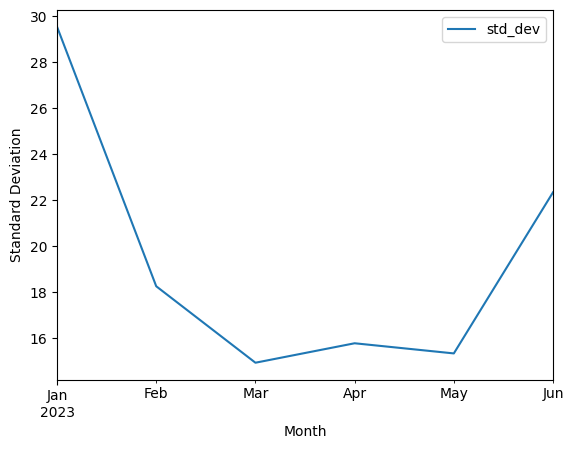

In [72]:
df_std_dev = (
    data_no_peaks['np_comparison']
    .resample('ME')
    .std()
    .to_frame(name='std_dev') 
)
df_std_dev.plot(kind='line', xlabel='Month', ylabel='Standard Deviation')